In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib as m
from tqdm import tqdm
from scipy import linalg
import scipy as sp
import os
import pickle
import glob
import h5py
import random

from scipy.constants import *

phi0 = physical_constants["mag. flux quantum"][0]
eps0 = epsilon_0

from scipy.special import eval_hermite
import scfitpy as Qfit

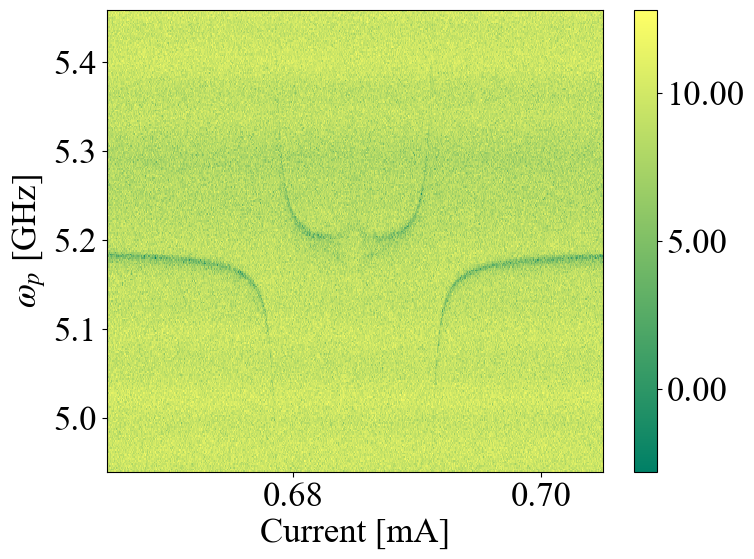

In [6]:
# Load test spectrum
_dat = np.load("./assets/cwSpec_currentSweep_202407011423.npz")
current = _dat["current"]  # mA
freq = _dat["freq"]  # GHz

mag1 = _dat["mag1"]  # 2d-spectrum date, dims=[freq, current]

fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams["font.size"] = 25
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

X, Y = np.meshgrid(freq, current)
mappable = ax.pcolor(Y, X, mag1, cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)

plt.xlabel(r"Current [mA]", fontsize=25)
plt.ylabel(r"$\omega_p\ $[GHz]", fontsize=25)
plt.show()

In [7]:
f = open("2Q_tracePT_band.pickle", "rb")
band_min = pickle.load(f)
f = open("2Q_tracePT_cur.pickle", "rb")
cur_p = pickle.load(f)

#### from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(8, 5))
plt.rcParams["font.size"] = 18
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"
X, Y = np.meshgrid(freq, current)
mappable = ax.pcolor(Y, X, Qfit.normalization(mag1), cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)

for i in range(len(band_min)):
    ax.plot(cur_p[i], band_min[i], "*", ms=1, label=str(i))

# ax.set_ylim([5,6])
ax.set_ylabel("Frequency [GHz]", fontsize=24)
ax.set_xlabel(r"I [mA]", fontsize=24)
fig.tight_layout()
# plt.savefig(save_dir+"/"+"-5555.png", bbox_inches="tight", pad_inches=0.5)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '2Q_tracePT_band.pickle'

In [ ]:
init_params = (3.5, 1.2, 5.18, 0.1e-3, 0.1e-3, 760, 6.8495e-01)

In [ ]:
current1 = np.linspace(np.min(current), np.max(current), 101) - init_params[6]
E1Q = Qfit.Rabi(current1, init_params)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
plt.rcParams["font.size"] = 19
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"


for i in range(len(band_min)):
    ax.plot(np.array(cur_p[i]) - init_params[6], band_min[i], "+", label=str(i))
ax.plot(current1, np.array(E1Q[1]) - np.array(E1Q[0]), "-.", color="b", label="01")
ax.plot(current1, np.array(E1Q[2]) - np.array(E1Q[0]), "-.", color="black", label="20")
ax.plot(current1, np.array(E1Q[3]) - np.array(E1Q[1]), "-.", color="g", label="31")

ax.set_ylim([5, 5.4])
# # ax.set_ylim([5.2,5.4])
plt.grid()
plt.xlabel(r"mA", fontsize=24)
plt.ylabel(r"$E/h\ $[GHz]", fontsize=22)
plt.legend(loc="upper right", ncol=1)
# plt.savefig("Large dispersive readout.png",dpi=700)
plt.show()

In [ ]:
def err(params):
    Ef = [[] for i in range(len(cur_p))]
    for i in tqdm([0, 1, 2]):
        Ef[i] = Qfit.Rabi(np.array(cur_p[i]) - params[6], params)

    ere1 = abs(band_min[0] - np.array(Ef[0][1]) + np.array(Ef[0][0]))
    ere2 = abs(band_min[1] - np.array(Ef[1][2]) + np.array(Ef[1][0]))
    ere3 = abs(band_min[2] - np.array(Ef[2][3]) + np.array(Ef[2][1]))
    err = 100 * [
        np.sum(ere1) / len(ere1),
        np.sum(ere2) / len(ere2),
        np.sum(ere3) / len(ere3),
        0,
        0,
        0,
        0,
    ]
    return err


Ere = err(init_params)
print(np.sum(Ere))

In [ ]:
# import time
# from scipy.optimize import leastsq
# start = time.time()

# fitparams=leastsq(err,init_params)#,jac='3-point',bounds=[[3,3,0.2,0.2,5,40,-2,-1e-2,0.54,-1e-2,-1e-2],[4,4,1,1,5.5,60,-1,0,0.55,1e-2,1e-2]])

# elapsed_time = time.time() - start
# print ("elapsed_time:{0}".format(elapsed_time/60) + "[min]")

# with open('PT_paper01.pickle', mode='wb') as fo:
#     pickle.dump(fitparams[0], fo)

In [ ]:
f = open("PT_paper01.pickle", "rb")
fitparams0 = pickle.load(f)
print(fitparams0)
E1Q = Qfit.Rabi(current1, fitparams0)
print(np.sum(err(fitparams0)))

In [ ]:
# Ip calculation
f2 = 684.4 * 1e-3
f3 = -539.4 * 1e-3
df = f2 - f3
fitparams0[5] * df * h * 1e9 / phi0

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams["font.size"] = 25
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

X, Y = np.meshgrid(freq, (current - fitparams0[6]) * fitparams0[5])
mappable = ax.pcolor(Y, X, Qfit.normalization(mag1), cmap="summer")
cbar_num_format = "%.2f"
cbar = plt.colorbar(mappable, ax=ax, format=cbar_num_format)


ax.plot(
    current1 * fitparams0[5],
    np.array(E1Q[1]) - np.array(E1Q[0]),
    "-.",
    lw=2,
    color="b",
    label="$\\omega_{10}$",
)
ax.plot(
    current1 * fitparams0[5],
    np.array(E1Q[2]) - np.array(E1Q[0]),
    "-.",
    lw=2,
    color="r",
    label="$\\omega_{20}$",
)
ax.plot(
    current1 * fitparams0[5],
    np.array(E1Q[3]) - np.array(E1Q[1]),
    "-.",
    lw=2,
    color="g",
    label="$\\omega_{31}$",
)

ax.set_ylim([min(freq), max(freq)])
# plt.grid()
plt.xlabel(r"$\varepsilon_1$ [GHz]", fontsize=25)
plt.ylabel(r"$\omega_p\ $[GHz]", fontsize=25)
plt.legend(
    loc="upper left",
    borderaxespad=0,
    labelspacing=0.2,
    ncol=1,
    labelcolor="black",
    facecolor="whitesmoke",
    framealpha=0.5,
)
plt.savefig("RabiFit.png", bbox_inches="tight", pad_inches=0.5, dpi=700)
plt.show()